In [1]:
# Parameters
name      = ""
fits_path = ""

In [2]:
# Parameters
name = "MUSE-M42-N-bin2_trim"
fits_path = "fits_ready/MUSE-M42-N-bin2_trim.fits"


In [3]:
import time
start_time = time.time()

In [4]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
import corner
import json
from astropy.io import fits
import lmfit
from lmfit.model import save_modelresult
# Add path to py_modules 
sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root
#import strucfunc                   
import bfunc
import bplot

In [5]:
with fits.open("fits_ready/" + name + ".fits") as hdul:
    hdr = hdul[0].header
    
#noise    = hdul[0].header['NOISE']
#m3D      = hdul[0].header['M3D']
#ra       = hdul[0].header['RA']
sig      = hdul[0].header['SIG']
sig2     = hdul[0].header['SIG2']
s0       = hdul[0].header['S0']
box_size = hdul[0].header['BOX_SIZE']
pc       = hdul[0].header['PC']
pix      = hdul[0].header['PIX']
line     = hdul[0].header['LINE']
binsize  = hdul[0].header['BINSIZE']

In [6]:
pc_per_arcsec = pc
data = name

In [7]:
from astropy.table import Table
t = Table.read(fits_path, hdu="TABLE")
data_in = t.to_pandas()


mask = np.array(data_in["N pairs"]) > 0
B        = np.array(data_in['Unweighted B(r)'])[mask]
r        = np.array(10 ** np.array(data_in['log10 r'])* pix * pc)[mask]

# Fit and Confidence intervals

## Non-Linear Least-Squares Fitting

In [8]:
# Merge first K points
K = 3
r[K] = np.mean(r[:K])
B[K] = np.mean(B[:K])
r = r[K:]
B = B[K:]

In [9]:
# Weights

relative_uncertainty = 0.015
weights = 1.0 / (relative_uncertainty * B)
large_scale = r > 0.3 * box_size
#weights[large_scale] /= 1.5
#weights[:1] /= 2.0

to_fit = r <= 0.6 * box_size
#to_fit = ~large_scale

In [10]:
model = lmfit.Model(bfunc.bfunc03s)
model.param_names

['r0', 'sig2', 'm', 's0', 'noise']

In [11]:
# Correlation length between 1/10 and 2 x box_size
model.set_param_hint("r0", value=0.1 * box_size, min=0.01 * box_size, max=2 * box_size)

# sig2 between 1/4 and 2 x max value of B(r)
#model.set_param_hint("sig2", value=0.5 * B.max(), min=0.25 * B.max(), max=2 * B.max())
model.set_param_hint(
    "sig2",
    value=0.5 * B[to_fit].max(),
    min=0.25 * B[to_fit].max(),
    max=2 * B[to_fit].max(),
)


# m between 1/2 and 5/3
model.set_param_hint("m", value=1.0, min=0.5, max=2.0)

# Seeing RMS between 0.1 and 1.5 arcsec
model.set_param_hint(
    "s0", value=0.5 * pc_per_arcsec, min=0.1 * pc_per_arcsec, max=1.5 * pc_per_arcsec
)

# Noise cannot be much larger than smallest B(r)
model.set_param_hint("noise", value=0.5 * B.min(), min=0.0, max=3 * B.min())

# box_size is fixed
# model.set_param_hint("box_size", value=box_size, vary=False)

In [12]:
pd.DataFrame(model.param_hints)

,r0,sig2,m,s0,noise
value,0.044761,10.157019,1.0,0.000994,0.648463
min,0.004476,5.078510,0.5,0.000199,0.000000
max,0.895224,40.628077,2.0,0.002982,3.890776


In [13]:
result = model.fit(B[to_fit], weights=weights[to_fit], r=r[to_fit])

In [14]:
result

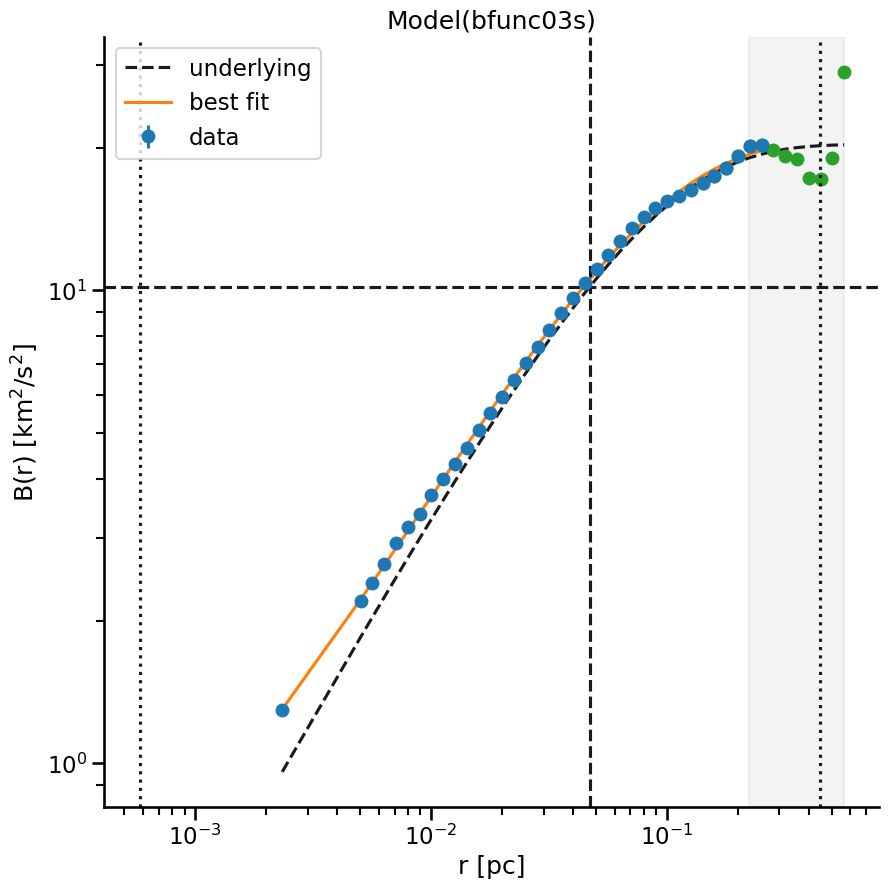

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the underlying model without instrumental effects
Bu = bfunc.bfunc00s(
    r, result.params["r0"].value, result.params["sig2"].value, result.params["m"].value
)
ax.plot(r, Bu, color="k", linestyle="dashed", label="underlying")

# Plot the fit results
result.plot_fit(ax=ax)

# Add in the points not included in fit
ax.plot(r[large_scale], B[large_scale], "o")

# Dotted lines for 2 x rms seeing and for box size
ax.axvline(2 * result.params["s0"].value, color="k", linestyle="dotted")
ax.axvline(box_size, color="k", linestyle="dotted")

# Dashed lines for best-fit r0 and sig2
ax.axvline(result.params["r0"].value, color="k", linestyle="dashed")
ax.axhline(result.params["sig2"].value, color="k", linestyle="dashed")

# Gray box to indicate the large scale values that are excluded from the fit
ax.axvspan(box_size / 2, r[-1], color="k", alpha=0.05, zorder=-1)

ax.set(
    xscale="log",
    yscale="log",
    xlabel="r [pc]",
    ylabel=r"B(r) [km$^{2}$/s$^{2}$]",
)
sns.despine()

## emcee

In [16]:
emcee_kws = dict(
    steps=25000, burn=1000, thin=50, is_weighted=True, progress=False, workers=1
)
emcee_params = result.params.copy()
# emcee_params.add('__lnsigma', value=np.log(0.1), min=np.log(0.001), max=np.log(2.0))

In [17]:
result_emcee = model.fit(
    data=B[to_fit],
    r=r[to_fit],
    weights=weights[to_fit],
    params=emcee_params,
    method="emcee",
    nan_policy="omit",
    fit_kws=emcee_kws,
)

In [18]:
result_emcee

Text(0, 0.5, 'acceptance fraction')

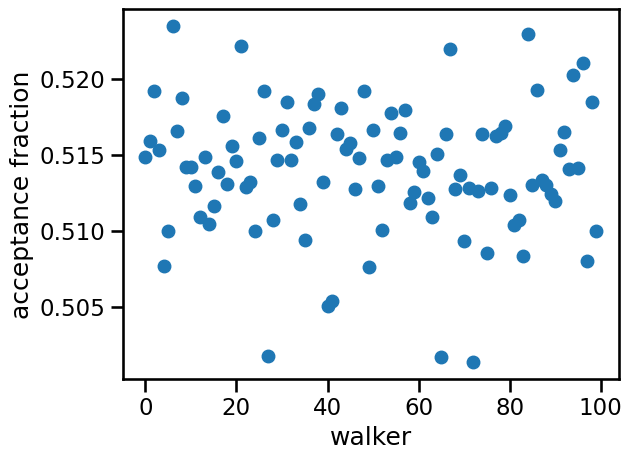

In [19]:
plt.plot(result_emcee.acceptance_fraction, "o")
plt.xlabel("walker")
plt.ylabel("acceptance fraction")



In [20]:
if hasattr(result_emcee, "acor"):
    print("Autocorrelation time for the parameters:")
    print("----------------------------------------")
    for i, p in enumerate(result_emcee.params):
        try:
            print(f"{p} = {result_emcee.acor[i]:.3f}")
        except IndexError:
            pass

Autocorrelation time for the parameters:
----------------------------------------
r0 = 64.837
sig2 = 63.940
m = 65.747
s0 = 79.591
noise = 79.752


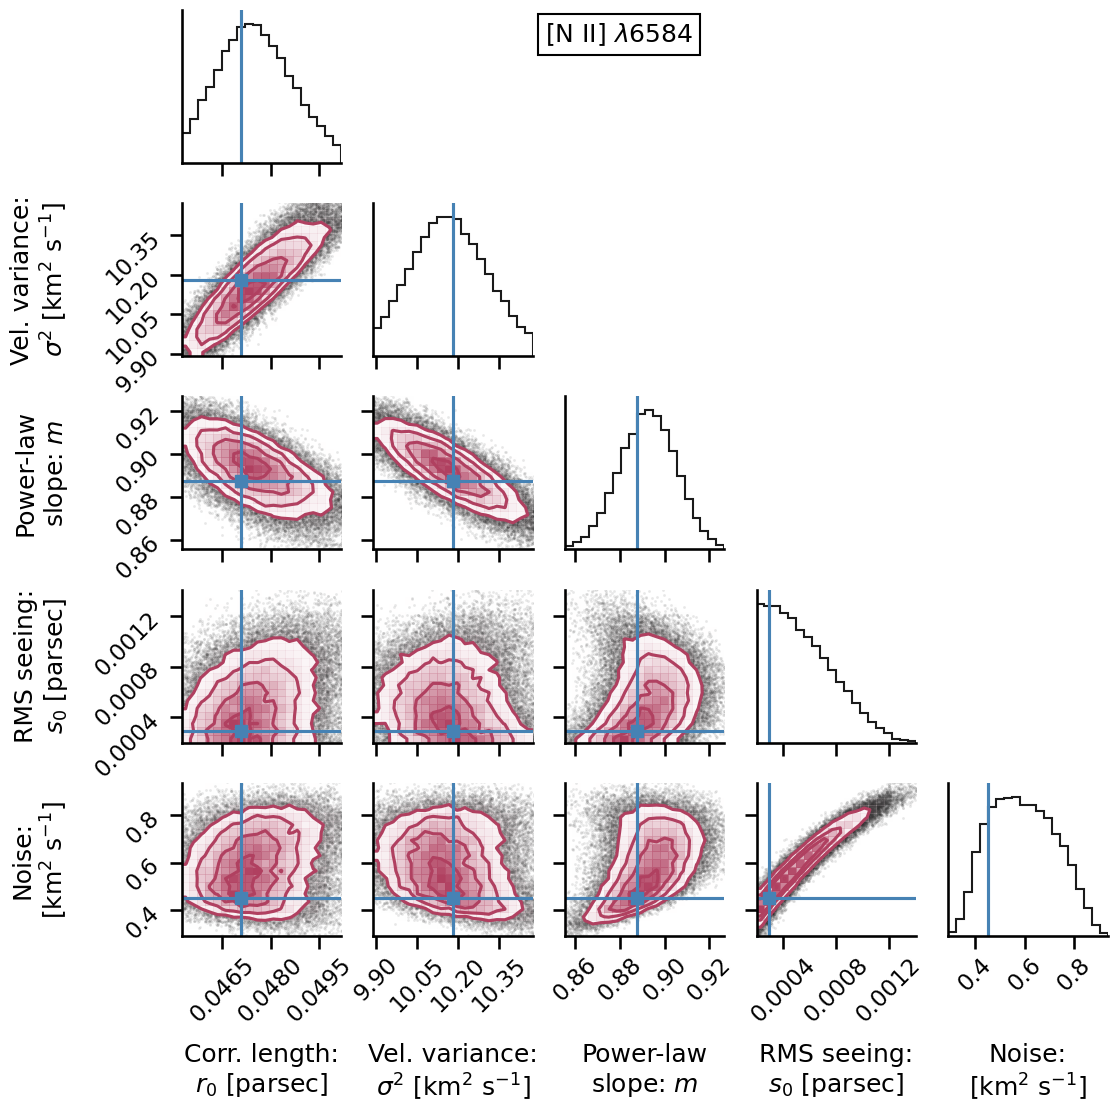

In [21]:
bplot.corner_plot(
    result_emcee, result, line, data, data_ranges=[0.95, 0.95, 0.995, 0.999, 0.999]
)

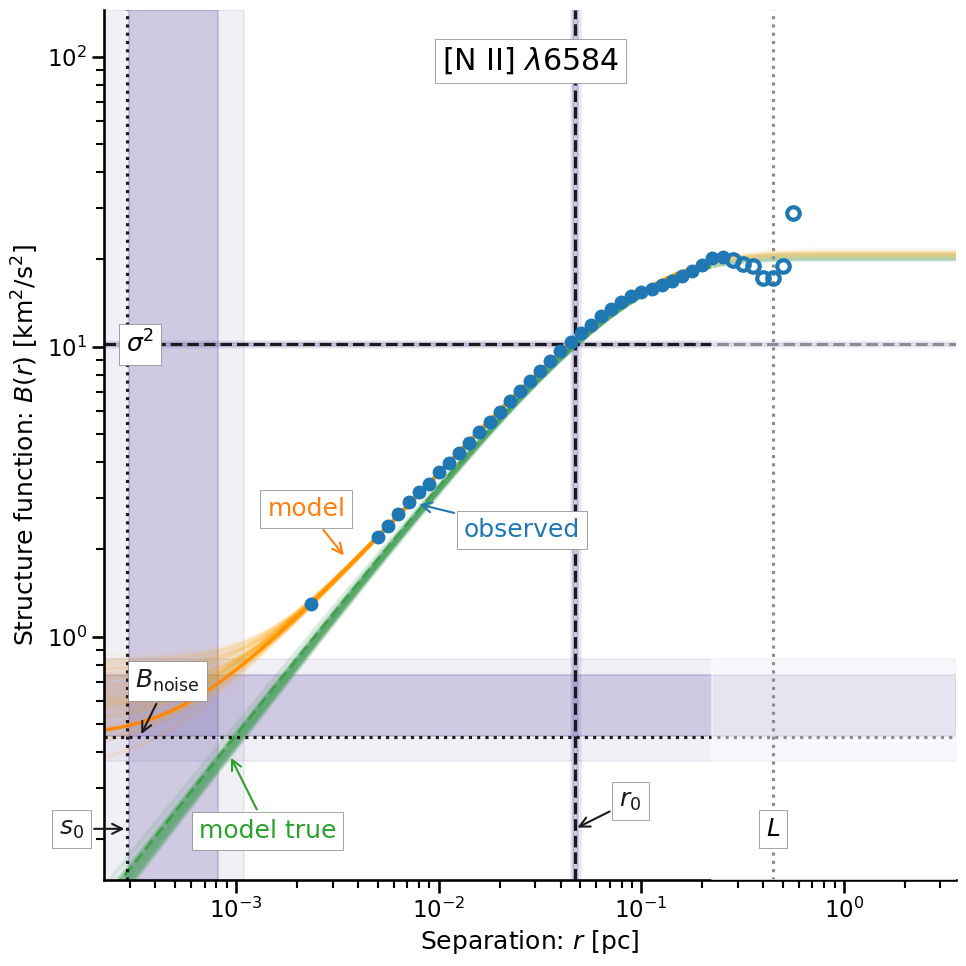

In [22]:
bplot.STYLE["data label element"] = 4
bplot.STYLE["model label element"] = 0
bplot.STYLE["model label offset"] = (-60, 40)
bplot.STYLE["true model label element"] = 7
bplot.STYLE["true model label offset"] = (30, -60)
bplot.strucfunc_plot(
    result_emcee, result, r, B, to_fit, line, data, box_size, large_scale
)

In [23]:
LM = {
    'sig2': [result.params['sig2'].value,result.params['sig2'].stderr],
    'r0': [result.params['r0'].value,result.params['r0'].stderr],
    'm' : [result.params['m'].value,result.params['m'].stderr],
    's0': [result.params['s0'].value,result.params['s0'].stderr],
    'noise' : [result.params['noise'].value,result.params['noise'].stderr]
}

In [24]:
MCMC = {
    'sig2': [result_emcee.params['sig2'].value,result_emcee.params['sig2'].stderr],
    'r0': [result_emcee.params['r0'].value,result_emcee.params['r0'].stderr],
    'm' : [result_emcee.params['m'].value,result_emcee.params['m'].stderr],
    's0': [result_emcee.params['s0'].value,result_emcee.params['s0'].stderr],
    'noise' : [result_emcee.params['noise'].value,result_emcee.params['noise'].stderr]
}

In [25]:
sig2s2 = np.percentile(result_emcee.flatchain['sig2'],[2.5, 97.5])
r0s2 = np.percentile(result_emcee.flatchain['r0'],[2.5, 97.5])
ms2 = np.percentile(result_emcee.flatchain['m'],[2.5, 97.5])
s0s2 = np.percentile(result_emcee.flatchain['s0'],[2.5, 97.5])
b0s2 = np.percentile(result_emcee.flatchain['noise'],[2.5, 97.5])

In [26]:
sig2s2p = sig2s2[1]-result.params['sig2'].value
sig2s2m = result.params['sig2'].value-sig2s2[0]

r0s2p = r0s2[1]-result.params['r0'].value
r0s2m = result.params['r0'].value-r0s2[0]

ms2p = ms2[1]-result.params['m'].value
ms2m = result.params['m'].value-ms2[0]

s0s2p = s0s2[1]-result.params['s0'].value
s0s2m = result.params['s0'].value-s0s2[0]

b0s2p = b0s2[1]-result.params['noise'].value
b0s2m = result.params['noise'].value-b0s2[0]

In [27]:
# MCMC 1 sigma confidence interval

sig2s1 = np.percentile(result_emcee.flatchain['sig2'],[16, 85])
r0s1 = np.percentile(result_emcee.flatchain['r0'],[16, 85])
ms1 = np.percentile(result_emcee.flatchain['m'],[16, 85])
s0s1 = np.percentile(result_emcee.flatchain['s0'],[16, 85])
b0s1 = np.percentile(result_emcee.flatchain['noise'],[16, 85])

sig2s1p = sig2s1[1]-result.params['sig2'].value
sig2s1m = result.params['sig2'].value-sig2s1[0]

r0s1p = r0s1[1]-result.params['r0'].value
r0s1m = result.params['r0'].value-r0s1[0]

ms1p = ms1[1]-result.params['m'].value
ms1m = result.params['m'].value-ms1[0]

s0s1p = s0s1[1]-result.params['s0'].value
s0s1m = result.params['s0'].value-s0s1[0]

b0s1p = b0s1[1]-result.params['noise'].value
b0s1m = result.params['noise'].value-b0s1[0]

In [28]:
#  LM + MCMC 2 sigma

results_2sig = {
    'sig2': [result.params['sig2'].value,sig2s2p,sig2s2m],
    'r0': [result.params['r0'].value,r0s2p,r0s2m],
    'm' : [result.params['m'].value,ms2p,ms2m],
    's0': [result.params['s0'].value,s0s2p,s0s2m],
    'noise' : [result.params['noise'].value,b0s2p,b0s2m] 
    
}

results_2sig

{'sig2': [10.179909730781485, 0.2930207095594888, 0.289414206700803],
 'r0': [0.047072056847540095, 0.0031066278668214556, 0.0018335555568455772],
 'm': [0.8875148757181449, 0.029252942170333807, 0.02063946034751052],
 's0': [0.00029014805299619755, 0.0008094455392058239, 7.652022414767482e-05],
 'noise': [0.4524087263508071, 0.38787153453772083, 0.07973963348968444]}

In [29]:
#save_modelresult(result, "results_fit/" + name + "result_ideal.sav")
#save_modelresult(result_emcee, "results_fit/" + name + "result_emcee_ideal.sav")

In [30]:
df = pd.DataFrame(results_2sig)

# Flatten MultiIndex columns
if isinstance(df.columns, pd.MultiIndex):
    df.columns = ["_".join(map(str, col)).strip() for col in df.columns.to_flat_index()]
else:
    df.columns = [str(c) for c in df.columns]

df = df.reset_index(drop=True)

t = Table.from_pandas(df)
new_hdu = fits.BinTableHDU(t, name="PARAMETERS")

with fits.open(fits_path, memmap=False) as hdul:
    hdus = [h.copy() for h in hdul]

# FITS EXTNAMEs are effectively case-insensitive; astropy reports them uppercase.
target = "PARAMETERS"
idxs = [i for i, h in enumerate(hdus) if h.name.upper() == target]

if idxs:
    i0 = idxs[0]
    # Optional: preserve existing header cards (metadata) from old PARAMETERS
    old_hdr = hdus[i0].header.copy()
    hdus[i0] = new_hdu
    # Keep old metadata, then ensure EXTNAME stays correct
    hdus[i0].header.update(old_hdr)
    hdus[i0].name = target
    # Remove any additional duplicates if they exist
    for j in reversed(idxs[1:]):
        del hdus[j]
else:
    # If it doesn't exist, add it
    hdus.append(new_hdu)

fits.HDUList(hdus).writeto(fits_path, overwrite=True)

In [31]:
# Test import

from astropy.table import Table
t = Table.read(fits_path, hdu="PARAMETERS")
df_loaded = t.to_pandas()
df_loaded

,sig2,r0,m,s0,noise
0,10.179910,0.047072,0.887515,0.000290,0.452409
1,0.293021,0.003107,0.029253,0.000809,0.387872
2,0.289414,0.001834,0.020639,0.000077,0.079740


In [32]:
hdul = fits.open(fits_path)
hdr = hdul[0].header
print(hdul.info())
print(hdr)

Filename: fits_ready/MUSE-M42-N-bin2_trim.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  MOM0          1 ImageHDU         8   (231, 343)   float64   
  2  MOM1          1 ImageHDU         8   (231, 343)   float64   
  3  MASK          1 ImageHDU         8   (231, 343)   uint8   
  4  TABLE         1 BinTableHDU     23   52R x 7C   [D, D, D, D, K, D, D]   
  5  PARAMETERS    1 BinTableHDU     19   3R x 5C   [D, D, D, D, D]   
None
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  FILE    = 'N_II-6583'          / Fits file name                                 NAME_ID = 'MUSE-M42-N-bin2_trim' / pipeline identifier                          REG     = 

None
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  FILE    = 'N_II-6583'          / Fits file name                                 NAME_ID = 'MUSE-M42-N-bin2_trim' / pipeline identifier                          REG     = 'M 42    '           / Region catalog name                            NAME_REG= 'Orion   '           / Region name                                    REG_ID  = 'M42     '           / Region identifier                              TYPE_OBJ= 'H II region'        / Type object                                    DIST    =                  410 / Distance in parsecs                            INSTR   = 'MUSE    '           / Instrument                                     LINE    = '[N II]$\ \lambda$6584' /

In [33]:
print("--- %s seconds ---" % (time.time() - start_time))

--- 786.6890833377838 seconds ---
